In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub

# Downloaded latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")


Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


In [ ]:
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120

In [ ]:
import pandas as pd
# The path variable holds the location where kagglehub downloaded the dataset
df = pd.read_csv(f'{path}/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.shape # 569 samples and 33 rows

(569, 33)

In [ ]:
df.columns # 33 columns include 1 id column(id), 1 target column (diagnosis- m for malignant,B for benign),
#30 numeric features(mean, se, worst values for various measurements)1 empty column (Unnamed: 32)


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.describe() # confirms unamed 32 is empty column 0.0/nan id - no analytical meaning for the prediction task, very large numerical values

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
# Features/target placeholders (full set; reduction later)
X_full = df.drop(columns=['diagnosis', 'diagnosis_num'])
y = df['diagnosis_num']

In [ ]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df['diagnosis_num'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
X_full = df.drop(columns=['diagnosis', 'diagnosis_num'])
y = df['diagnosis_num']

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_num
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


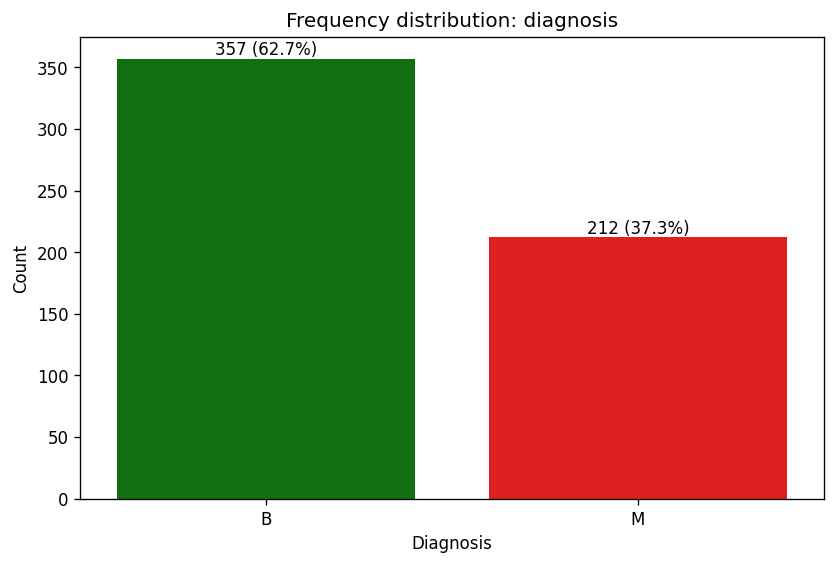

In [ ]:
order = ['B', 'M']
counts = df['diagnosis'].value_counts().reindex(order)
percentages = df['diagnosis'].value_counts(normalize=True).reindex(order) * 100

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='diagnosis', order=order, palette={'B':'green', 'M':'red'})

for i, p in enumerate(ax.patches):
    count = counts.iloc[i]
    pct = percentages.iloc[i]
    ax.annotate(f'{count:.0f} ({pct:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Frequency distribution: diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


In [ ]:
# Overall summary
display(df.describe().T)

# Summary by class (compact)
display(df.groupby('diagnosis')['diagnosis_num'].count().rename('count'))


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,count
diagnosis,
B,357
M,212


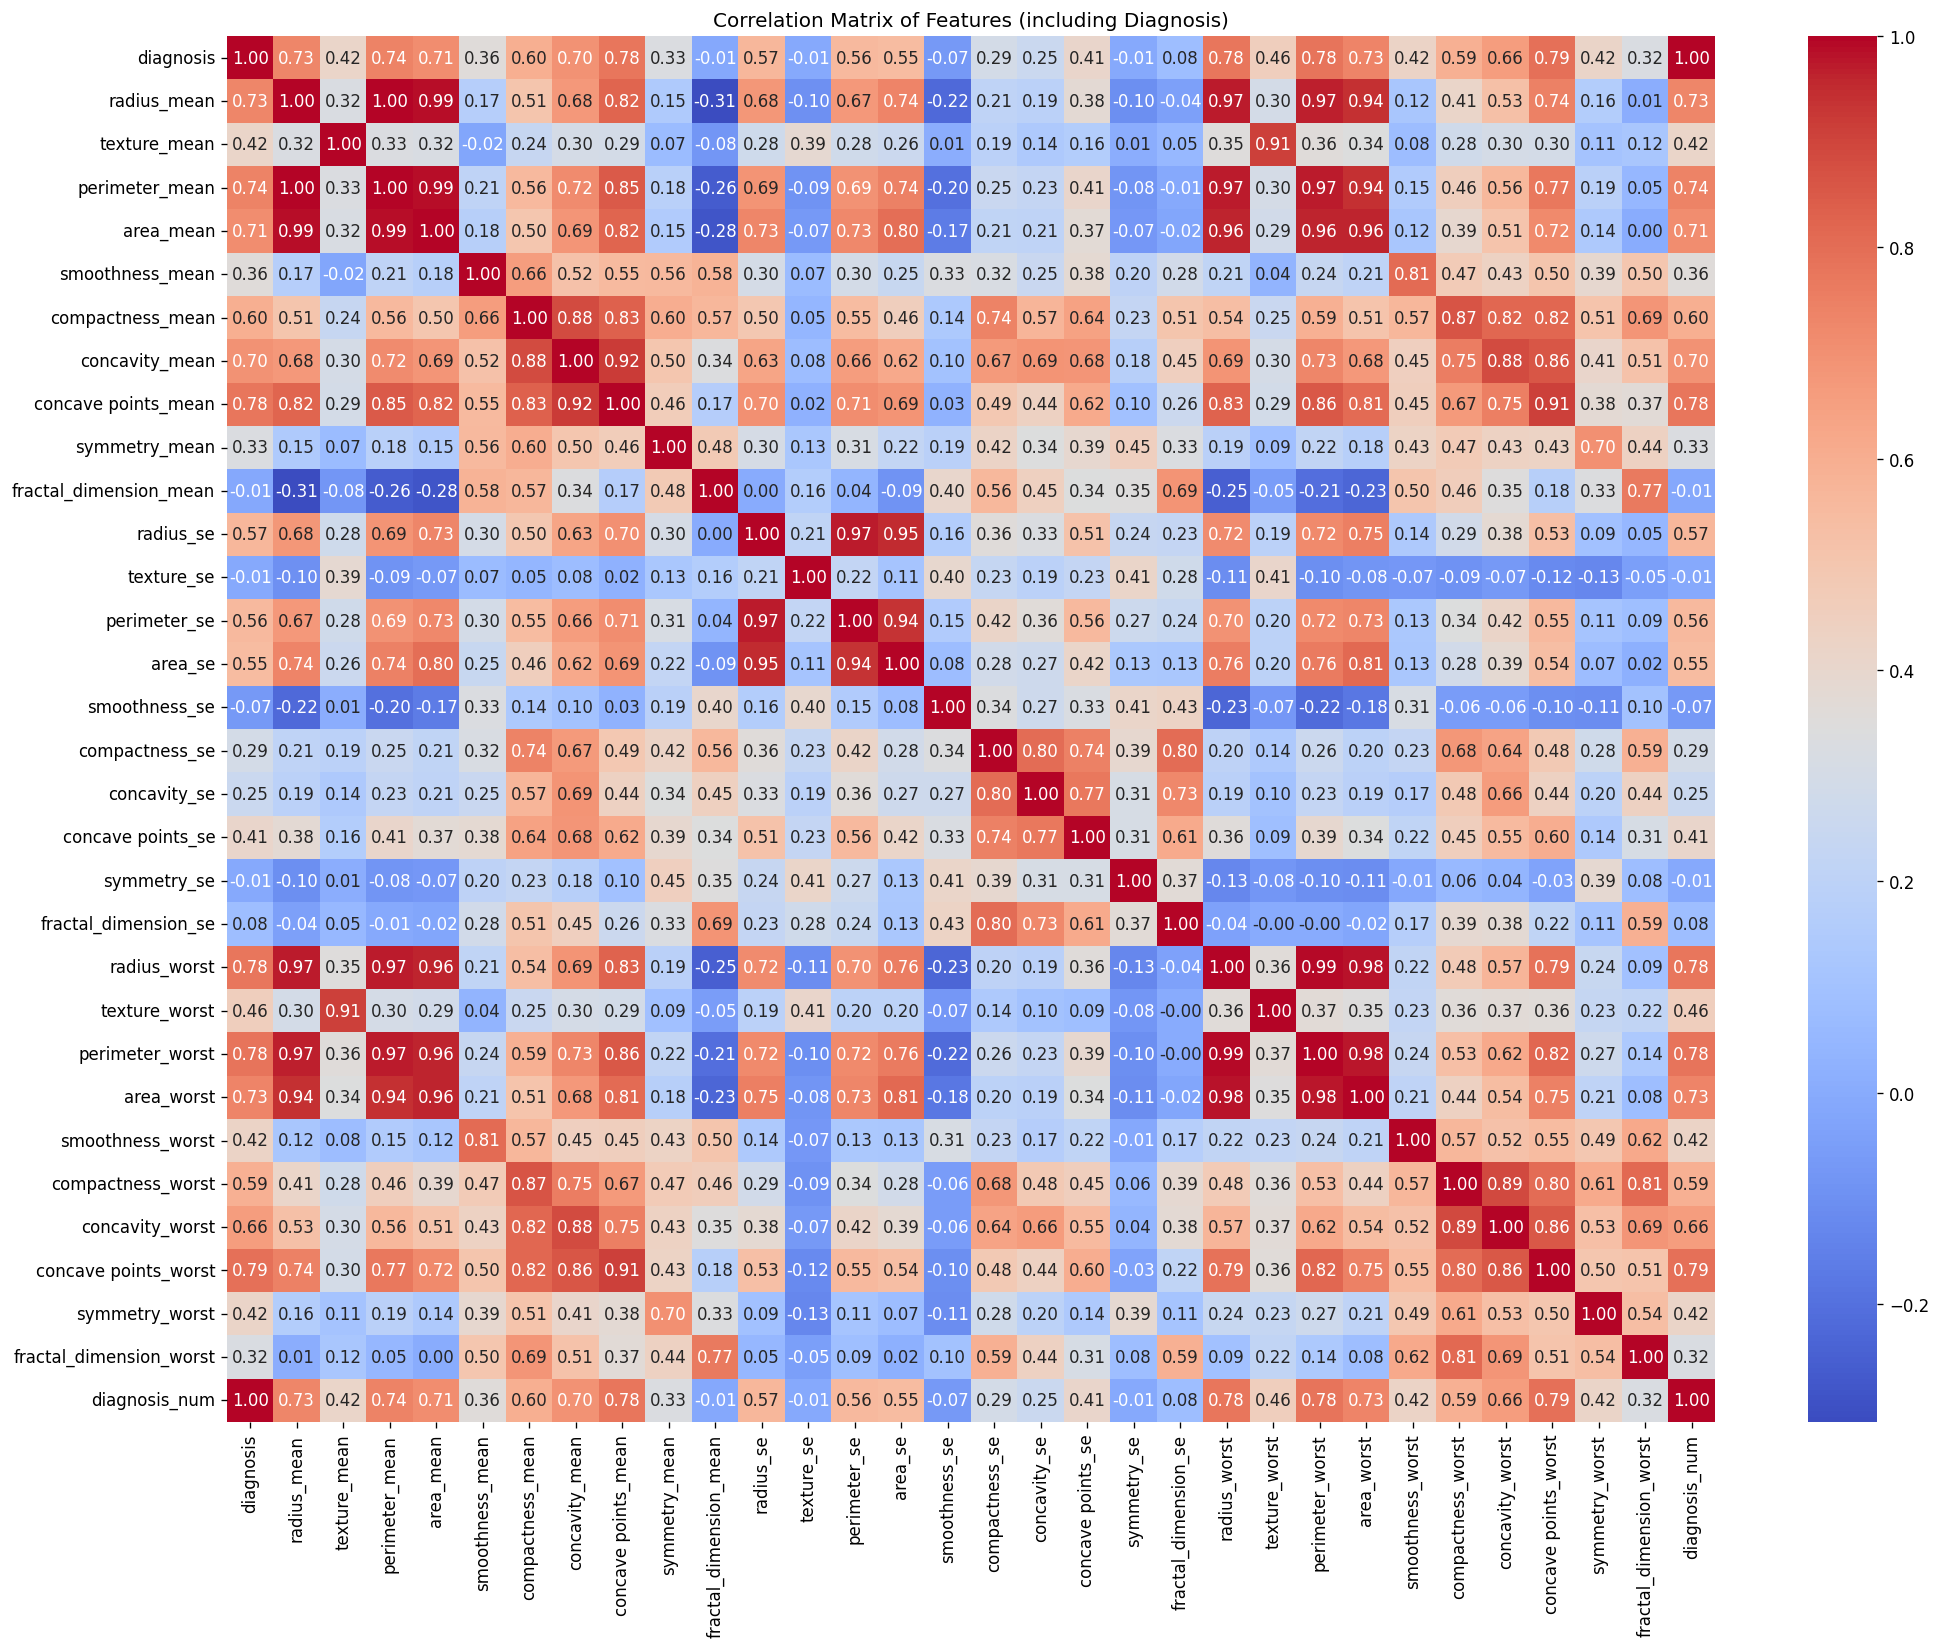

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
# Mapped 'diagnosis' to numerical values before calculating correlation
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
# Calculated the correlation matrix for all columns including the numerical 'diagnosis'
corr_matrix = df.corr()
# Visualised the correlation matrix using a heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features (including Diagnosis)')
plt.savefig('correlation_matrix.png')
plt.show()

In [ ]:
from sklearn.metrics import r2_score

size_features = ['radius_mean', 'perimeter_mean', 'area_mean']
for i in range(len(size_features)):
    for j in range(i+1, len(size_features)):
        f1, f2 = size_features[i], size_features[j]
        # Symmetric R² proxy via Pearson r^2 (since feature→feature regression is arbitrary)
        r = X_full[[f1, f2]].corr().iloc[0,1]
        print(f"|r|^2 ~ R²({f1}, {f2}) ≈ {r**2:.4f} (|r|={abs(r):.4f})")


|r|^2 ~ R²(radius_mean, perimeter_mean) ≈ 0.9957 (|r|=0.9979)
|r|^2 ~ R²(radius_mean, area_mean) ≈ 0.9749 (|r|=0.9874)
|r|^2 ~ R²(perimeter_mean, area_mean) ≈ 0.9732 (|r|=0.9865)


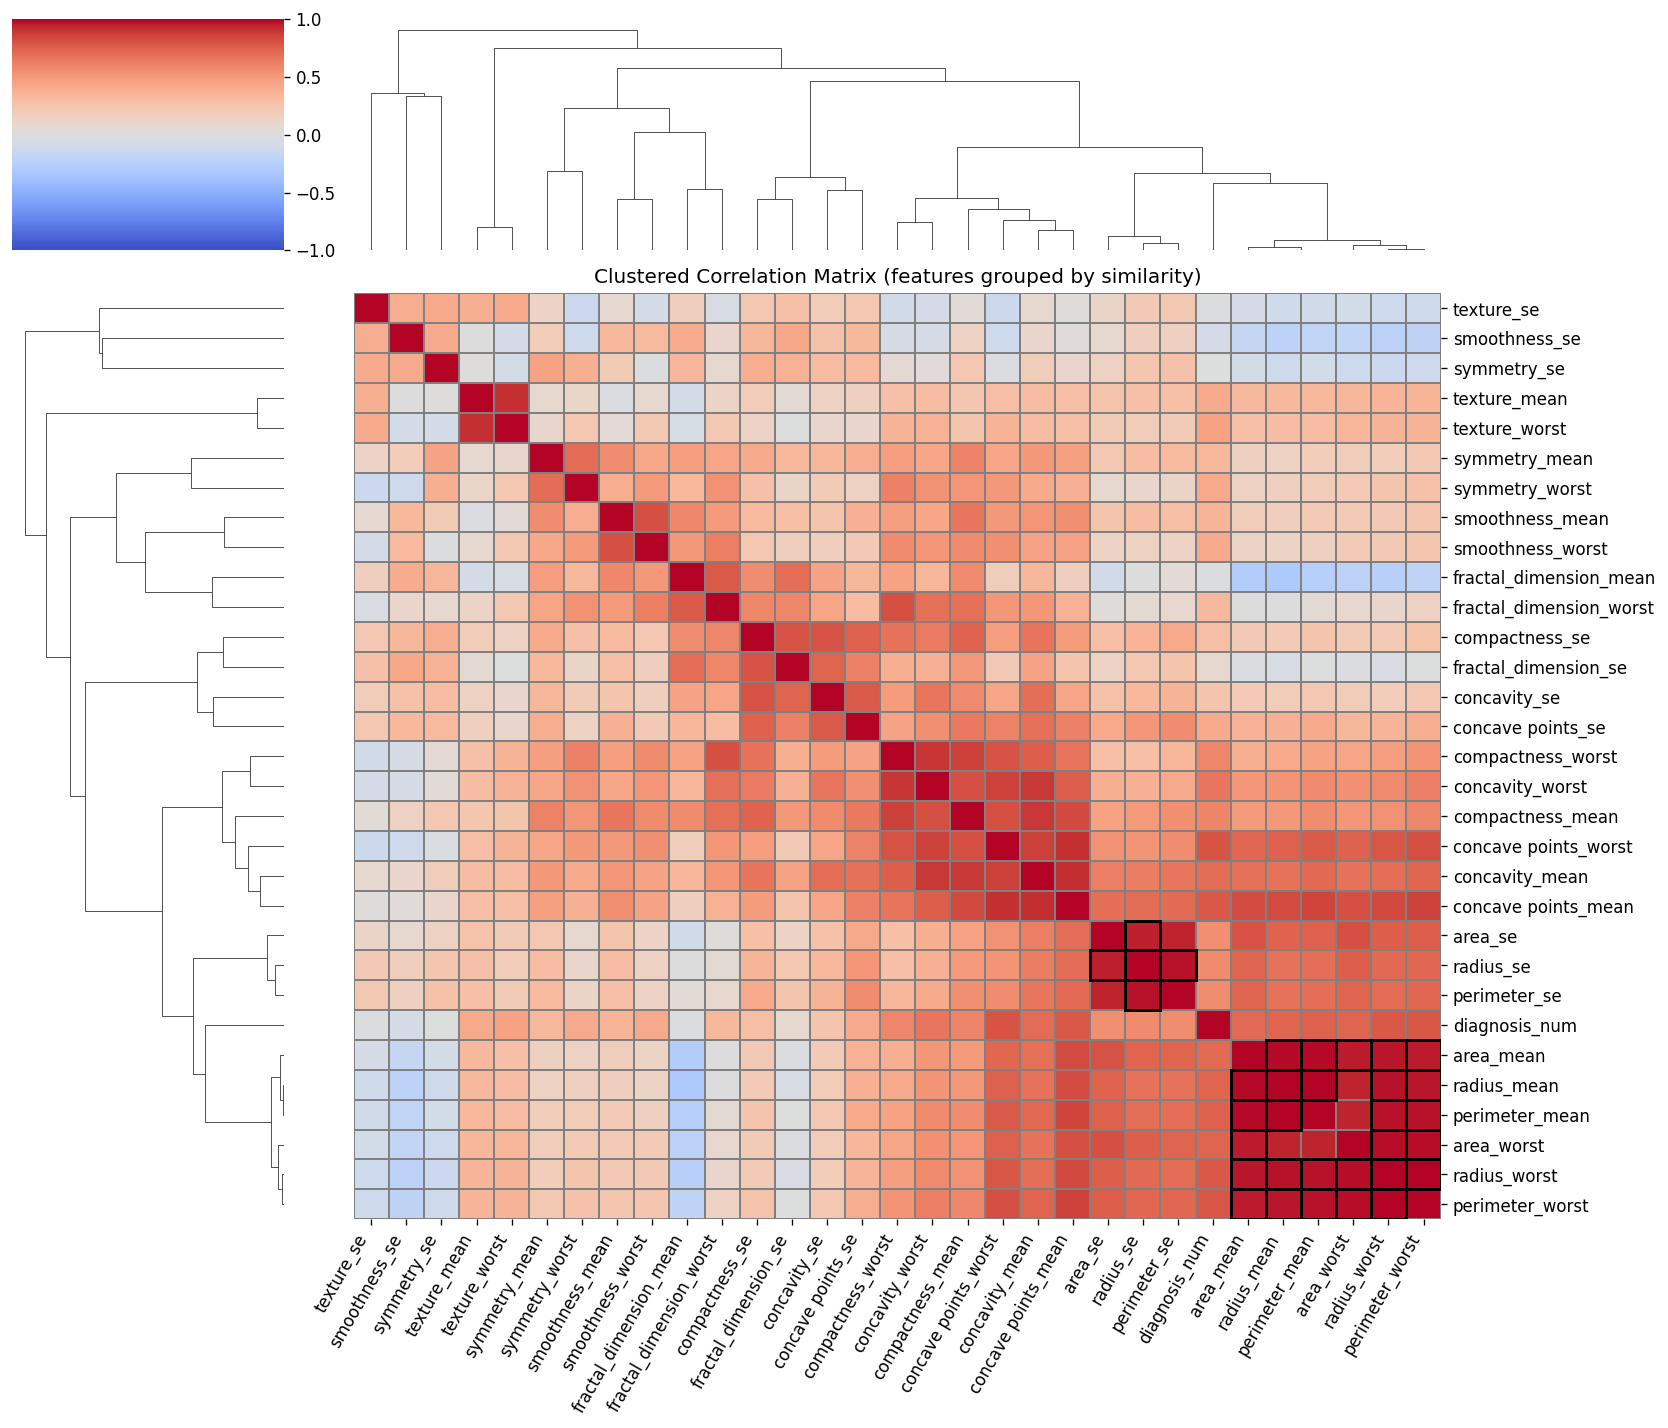


Clusters using |r| ≥ 0.95 (distance ≤ 0.050000000000000044):
  Cluster 24 (6 features): ['radius_mean', 'perimeter_mean', 'area_mean', 'radius_worst', 'perimeter_worst', 'area_worst']
  Cluster 22 (2 features): ['radius_se', 'perimeter_se']

Suggested representative features (one per high-corr cluster):
['radius_worst', 'radius_se']

Redundant features you could drop to reduce multicollinearity:
['area_mean', 'area_worst', 'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'radius_mean']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster

# Features only
X = df.drop(columns=['id','Unnamed: 32','diagnosis'], errors='ignore').copy()

# Correlation + distance
corr = X.corr() # Pearson correlation
dist = 1 - corr.abs() # correlation distance in [0,2]; smaller = more similar

#Hierarchical clustering on features
# condensed distance matrix for linkage
Z = linkage(squareform(dist, checks=False), method='average')
order = leaves_list(Z)
ordered_feats = corr.index[order]
corr_ord = corr.loc[ordered_feats, ordered_feats]

# Clustered heatmap with dendrogram
g = sns.clustermap(
    corr, row_linkage=Z, col_linkage=Z,
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.2, linecolor='gray',
    figsize=(14, 12), cbar_kws={'shrink': .8},
    annot=False
)
g.ax_heatmap.set_title("Clustered Correlation Matrix (features grouped by similarity)")
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=60, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.tight_layout()
g.savefig("wdbc_corr_clustermap.png", dpi=200)

# Highlighted |r| > 0.95 cells on the clustermap
ax = g.ax_heatmap
# Map feature position on the clustered axis
pos = {feat: i for i, feat in enumerate(ordered_feats)}
thr = 0.95
for i, f1 in enumerate(ordered_feats):
    for j, f2 in enumerate(ordered_feats):
        if i == j:
            continue
        r = corr.loc[f1, f2]
        if abs(r) > thr:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=1.8))

plt.tight_layout()
g.savefig("wdbc_corr_clustermap_highlight.png", dpi=200)
plt.show()

# Print clusters and suggest representatives
# Cluster by correlation-distance threshold corresponding to |r| >= r0
r0 = 0.95
t = 1 - r0 # distance threshold (e.g., 0.05 for r>=0.95)
labels = fcluster(Z, t=t, criterion='distance')

clusters = {}
for feat, lab in zip(corr.index, labels):
    clusters.setdefault(lab, []).append(feat)

# Sort clusters by size (largest first) and print
clusters = dict(sorted(clusters.items(), key=lambda kv: -len(kv[1])))

print(f"\nClusters using |r| ≥ {r0} (distance ≤ {t}):")
for cid, feats in clusters.items():
    if len(feats) == 1:
        continue # singletons are not high-corr groups
    print(f"  Cluster {cid} ({len(feats)} features): {feats}")

# keep one per cluster (the first in the ordered list)
reps = []
dropped = []
for cid, feats in clusters.items():
    if len(feats) == 1:
        continue
    # choose the feature that has the highest average |corr| within the cluster
    sub = corr.loc[feats, feats].abs()
    rep = sub.mean().sort_values(ascending=False).index[0]
    reps.append(rep)
    dropped.extend([f for f in feats if f != rep])

print("\nSuggested representative features (one per high-corr cluster):")
print(reps)
print("\nRedundant features you could drop to reduce multicollinearity:")
print(sorted(set(dropped)))


In [ ]:
#Clustered correlation with black boxes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import fcluster

# 0) Build a clean correlation matrix from features
corr = pd.DataFrame(X).corr(numeric_only=True)
corr = corr.replace([np.inf, -np.inf], np.nan).fillna(0)

# 1) clustered heatmap (with dendrograms)
sns.set(font_scale=0.6)
cg = sns.clustermap(
    corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    row_cluster=True, col_cluster=True,
    linewidths=0, figsize=(9, 9),
    cbar_kws={"label": "Pearson r"}
)
cg.fig.suptitle("Clustered Correlation Matrix (features grouped by similarity)", y=1.02)

# 2) Added black boxes around contiguous clusters on the reordered heatmap
# the dendrogram is cut into N clusters
maxclust = 6  # <= adjust to taste; higher -> more/smaller boxes
min_size = 3  # only draw boxes for clusters at least this big

# linkage & order used by seaborn
Z = cg.dendrogram_row.linkage
order = cg.dendrogram_row.reordered_ind

# cluster labels in original order, then reordered to match heatmap
labels = fcluster(Z, t=maxclust, criterion="maxclust")
labels = labels[np.array(order)]

# find contiguous runs of the same label (these form the square blocks)
start = 0
for i in range(1, len(labels) + 1):
    if i == len(labels) or labels[i] != labels[start]:
        length = i - start
        if length >= min_size:
            # draw a square on the heatmap (x,y same because corr is symmetric)
            rect = Rectangle(
                (start, start),              # (x0, y0)
                length, length,              # width, height
                fill=False, edgecolor="black", linewidth=1.8
            )
            cg.ax_heatmap.add_patch(rect)
        start = i

clustered_boxed_path = "clustered_corr_boxed.png"
cg.savefig(clustered_boxed_path, dpi=300, bbox_inches="tight")
plt.close(cg.fig)

# 3) Standard annotated correlation heatmap (numbers shown)
fig, ax = plt.subplots(figsize=(9, 9), dpi=300)
sns.heatmap(
    corr, ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size":5},
    cbar_kws={"label": "Pearson r"}
)
ax.set_title("Correlation Matrix (with coefficients)")
ax.tick_params(axis="x", labelrotation=90, labelsize=6)
ax.tick_params(axis="y", labelrotation=0, labelsize=6)
plt.tight_layout()
annotated_path = "annot_corr.png"
fig.savefig(annotated_path, dpi=300, bbox_inches="tight")
plt.close(fig)

# 4) both images side by side
img_left  = mpimg.imread(clustered_boxed_path)
img_right = mpimg.imread(annotated_path)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=300)
axes[0].imshow(img_left);  axes[0].set_title("Clustered + boxes"); axes[0].axis("off")
axes[1].imshow(img_right); axes[1].set_title("Annotated coefficients"); axes[1].axis("off")
plt.tight_layout()
combined_path = "corr_side_by_side_boxed.png"
fig.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()



Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Correlation threshold mapping R^2>=0.94 → |r|>=sqrt(0.94)≈0.9695
CORR_THRESHOLD = 0.97

corr_abs = X_full.corr().abs()
np.fill_diagonal(corr_abs.values, 0.0)

features = list(X_full.columns)
visited = set()
clusters = []

for f in features:
    if f in visited:
        continue
    stack = [f]; comp = []
    while stack:
        cur = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        comp.append(cur)
        neighbors = corr_abs.index[(corr_abs.loc[cur] > CORR_THRESHOLD)].tolist()
        stack.extend([n for n in neighbors if n not in visited])
    clusters.append(sorted(comp))

from sklearn.metrics import roc_auc_score
def dir_agnostic_auc(vals, yy):
    auc = roc_auc_score(yy, vals)
    return max(auc, 1 - auc)

feat_auc = {f: dir_agnostic_auc(X_full[f].values, y.values) for f in features}

kept = []
drop_map = {}
for comp in clusters:
    if len(comp) == 1:
        kept.append(comp[0]); drop_map[comp[0]] = []
    else:
        best = max(comp, key=lambda z: feat_auc[z])
        kept.append(best); drop_map[best] = [z for z in comp if z != best]

kept = sorted(kept)
dropped = sorted(list(set(features) - set(kept)))

print(f"Original features: {len(features)} | Kept: {len(kept)} | Dropped: {len(dropped)}")
print("\nClusters (|r| > {:.2f}):".format(CORR_THRESHOLD))
for comp in clusters:
    if len(comp) > 1:
        best = max(comp, key=lambda z: feat_auc[z])
        print(f"  {comp} | kept: {best} (AUC={feat_auc[best]:.4f})")
    else:
        print(f"  {comp} | kept: {comp[0]} (AUC={feat_auc[comp[0]]:.4f})")

X_reduced = X_full[kept]
print("\nKept features:", kept)


Original features: 30 | Kept: 24 | Dropped: 6

Clusters (|r| > 0.97):
  ['area_mean', 'area_worst', 'perimeter_mean', 'perimeter_worst', 'radius_mean', 'radius_worst'] | kept: perimeter_worst (AUC=0.9755)
  ['texture_mean'] | kept: texture_mean (AUC=0.7758)
  ['smoothness_mean'] | kept: smoothness_mean (AUC=0.7220)
  ['compactness_mean'] | kept: compactness_mean (AUC=0.8638)
  ['concavity_mean'] | kept: concavity_mean (AUC=0.9378)
  ['concave points_mean'] | kept: concave points_mean (AUC=0.9644)
  ['symmetry_mean'] | kept: symmetry_mean (AUC=0.6986)
  ['fractal_dimension_mean'] | kept: fractal_dimension_mean (AUC=0.5155)
  ['perimeter_se', 'radius_se'] | kept: perimeter_se (AUC=0.8764)
  ['texture_se'] | kept: texture_se (AUC=0.5116)
  ['area_se'] | kept: area_se (AUC=0.9264)
  ['smoothness_se'] | kept: smoothness_se (AUC=0.5312)
  ['compactness_se'] | kept: compactness_se (AUC=0.7273)
  ['concavity_se'] | kept: concavity_se (AUC=0.7808)
  ['concave points_se'] | kept: concave points_

,Accuracy (mean±sd),Precision,Recall,F1-score,ROC-AUC
SVM,0.9719 ± 0.0225,0.9656,0.9621,0.9626,0.9958


SVM Confusion Matrix: TP=204, TN=349, FP=8, FN=8, FNR=3.77%


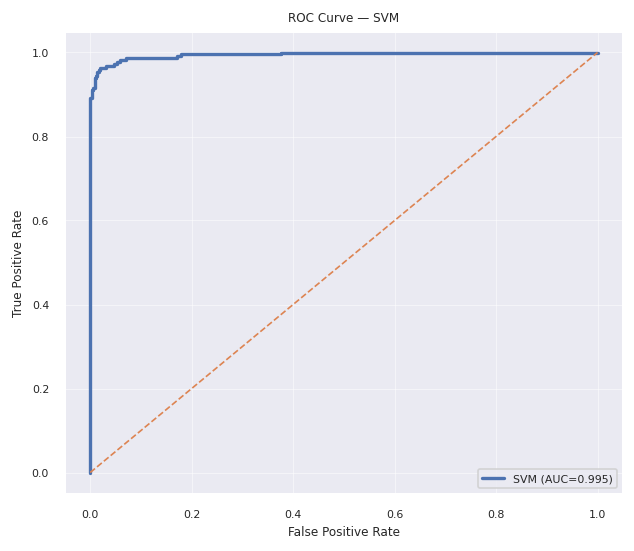

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, make_scorer, confusion_matrix, roc_curve, auc)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure labels are ints {0,1}
y = y.astype(int)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
}

# Cross-validated metrics
cvres = cross_validate(svm_pipe, X_reduced, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
svm_results = pd.DataFrame({
    "Accuracy (mean±sd)": [f"{cvres['test_accuracy'].mean():.4f} ± {cvres['test_accuracy'].std():.4f}"],
    "Precision": [f"{cvres['test_precision'].mean():.4f}"],
    "Recall": [f"{cvres['test_recall'].mean():.4f}"],
    "F1-score": [f"{cvres['test_f1'].mean():.4f}"],
    "ROC-AUC": [f"{cvres['test_roc_auc'].mean():.4f}"],
}, index=["SVM"])
display(svm_results)

# Aggregate confusion matrix + FNR from out-of-fold predictions
y_prob = cross_val_predict(svm_pipe, X_reduced, y, cv=cv, method="predict_proba", n_jobs=-1)
y_pred = (y_prob[:, 1] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
print(f"SVM Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}, FNR={fn/(fn+tp+1e-12):.2%}")

# ROC curve
fpr, tpr, _ = roc_curve(y, y_prob[:, 1])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"SVM (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1], [0,1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM")
plt.legend(loc="lower right")
plt.grid(True, linewidth=0.3)
plt.show()

,Accuracy (mean±sd),Precision,Recall,F1-score,ROC-AUC
RF,0.9596 ± 0.0248,0.9709,0.9193,0.9432,0.9923


RF Confusion Matrix: TP=195, TN=351, FP=6, FN=17, FNR=8.02%


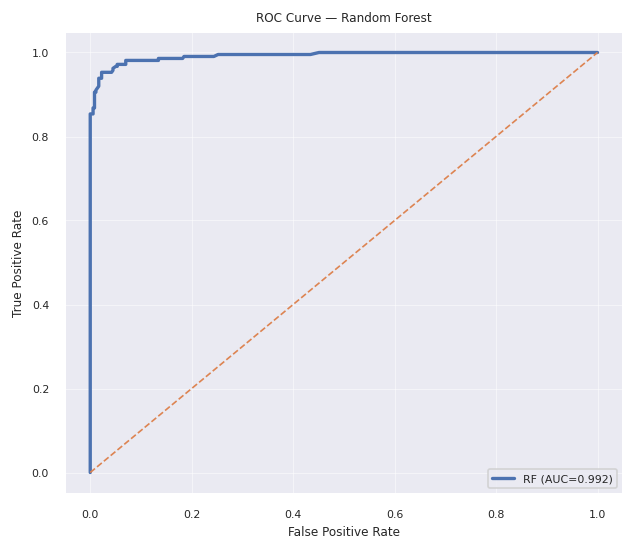

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, make_scorer, confusion_matrix, roc_curve, auc)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = y.astype(int)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rf_pipe = Pipeline([
    ("scaler", StandardScaler()),  # harmless for trees; keeps uniform pipeline structure
    ("clf", RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced_subsample"))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
}

cvres = cross_validate(rf_pipe, X_reduced, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
rf_results = pd.DataFrame({
    "Accuracy (mean±sd)": [f"{cvres['test_accuracy'].mean():.4f} ± {cvres['test_accuracy'].std():.4f}"],
    "Precision": [f"{cvres['test_precision'].mean():.4f}"],
    "Recall": [f"{cvres['test_recall'].mean():.4f}"],
    "F1-score": [f"{cvres['test_f1'].mean():.4f}"],
    "ROC-AUC": [f"{cvres['test_roc_auc'].mean():.4f}"],
}, index=["RF"])
display(rf_results)

y_prob = cross_val_predict(rf_pipe, X_reduced, y, cv=cv, method="predict_proba", n_jobs=-1)
y_pred = (y_prob[:, 1] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
print(f"RF Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}, FNR={fn/(fn+tp+1e-12):.2%}")

fpr, tpr, _ = roc_curve(y, y_prob[:, 1])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"RF (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1], [0,1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend(loc="lower right"); plt.grid(True, linewidth=0.3); plt.show()

,Accuracy (mean±sd),Precision,Recall,F1-score,ROC-AUC
KNN,0.9578 ± 0.0225,0.9799,0.9054,0.9402,0.9825


KNN Confusion Matrix: TP=192, TN=353, FP=4, FN=20, FNR=9.43%


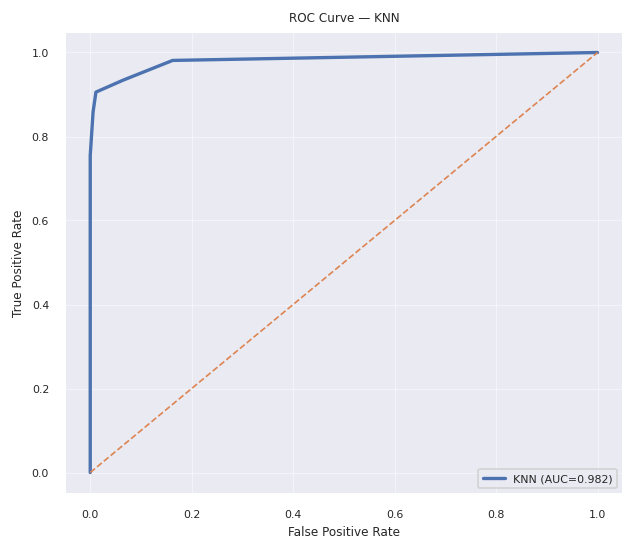

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, make_scorer, confusion_matrix, roc_curve, auc)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = y.astype(int)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
}

cvres = cross_validate(knn_pipe, X_reduced, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
knn_results = pd.DataFrame({
    "Accuracy (mean±sd)": [f"{cvres['test_accuracy'].mean():.4f} ± {cvres['test_accuracy'].std():.4f}"],
    "Precision": [f"{cvres['test_precision'].mean():.4f}"],
    "Recall": [f"{cvres['test_recall'].mean():.4f}"],
    "F1-score": [f"{cvres['test_f1'].mean():.4f}"],
    "ROC-AUC": [f"{cvres['test_roc_auc'].mean():.4f}"],
}, index=["KNN"])
display(knn_results)

y_prob = cross_val_predict(knn_pipe, X_reduced, y, cv=cv, method="predict_proba", n_jobs=-1)
y_pred = (y_prob[:, 1] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
print(f"KNN Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}, FNR={fn/(fn+tp+1e-12):.2%}")

fpr, tpr, _ = roc_curve(y, y_prob[:, 1])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"KNN (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1], [0,1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN")
plt.legend(loc="lower right"); plt.grid(True, linewidth=0.3); plt.show()

,Accuracy (mean±sd),Precision,Recall,F1-score,ROC-AUC
LR,0.9719 ± 0.0195,0.9685,0.9574,0.9619,0.9932


LR Confusion Matrix: TP=203, TN=350, FP=7, FN=9, FNR=4.25%


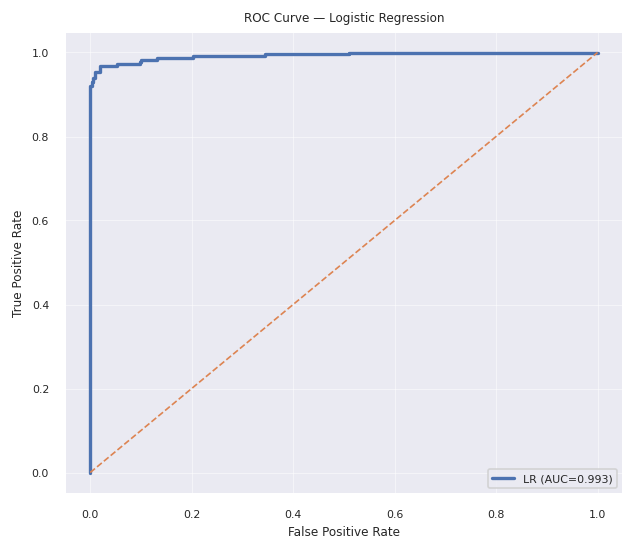

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, make_scorer, confusion_matrix, roc_curve, auc)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = y.astype(int)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=42))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
}

cvres = cross_validate(lr_pipe, X_reduced, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
lr_results = pd.DataFrame({
    "Accuracy (mean±sd)": [f"{cvres['test_accuracy'].mean():.4f} ± {cvres['test_accuracy'].std():.4f}"],
    "Precision": [f"{cvres['test_precision'].mean():.4f}"],
    "Recall": [f"{cvres['test_recall'].mean():.4f}"],
    "F1-score": [f"{cvres['test_f1'].mean():.4f}"],
    "ROC-AUC": [f"{cvres['test_roc_auc'].mean():.4f}"],
}, index=["LR"])
display(lr_results)

y_prob = cross_val_predict(lr_pipe, X_reduced, y, cv=cv, method="predict_proba", n_jobs=-1)
y_pred = (y_prob[:, 1] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
print(f"LR Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}, FNR={fn/(fn+tp+1e-12):.2%}")

fpr, tpr, _ = roc_curve(y, y_prob[:, 1])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"LR (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1], [0,1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend(loc="lower right"); plt.grid(True, linewidth=0.3); plt.show()

,Accuracy (mean±sd),Precision,Recall,F1-score,ROC-AUC
ANN,0.9754 ± 0.0225,0.9782,0.9574,0.9662,0.9901


ANN Confusion Matrix: TP=203, TN=352, FP=5, FN=9, FNR=4.25%


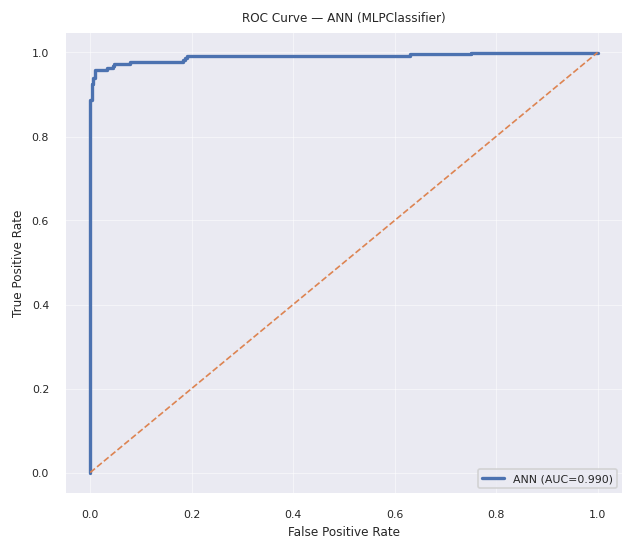

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, make_scorer, confusion_matrix, roc_curve, auc)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y = y.astype(int)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

ann_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", max_iter=2000, random_state=42))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
}

cvres = cross_validate(ann_pipe, X_reduced, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
ann_results = pd.DataFrame({
    "Accuracy (mean±sd)": [f"{cvres['test_accuracy'].mean():.4f} ± {cvres['test_accuracy'].std():.4f}"],
    "Precision": [f"{cvres['test_precision'].mean():.4f}"],
    "Recall": [f"{cvres['test_recall'].mean():.4f}"],
    "F1-score": [f"{cvres['test_f1'].mean():.4f}"],
    "ROC-AUC": [f"{cvres['test_roc_auc'].mean():.4f}"],
}, index=["ANN"])
display(ann_results)

y_prob = cross_val_predict(ann_pipe, X_reduced, y, cv=cv, method="predict_proba", n_jobs=-1)
y_pred = (y_prob[:, 1] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
print(f"ANN Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}, FNR={fn/(fn+tp+1e-12):.2%}")

fpr, tpr, _ = roc_curve(y, y_prob[:, 1])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"ANN (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1], [0,1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ANN (MLPClassifier)")
plt.legend(loc="lower right"); plt.grid(True, linewidth=0.3); plt.show()

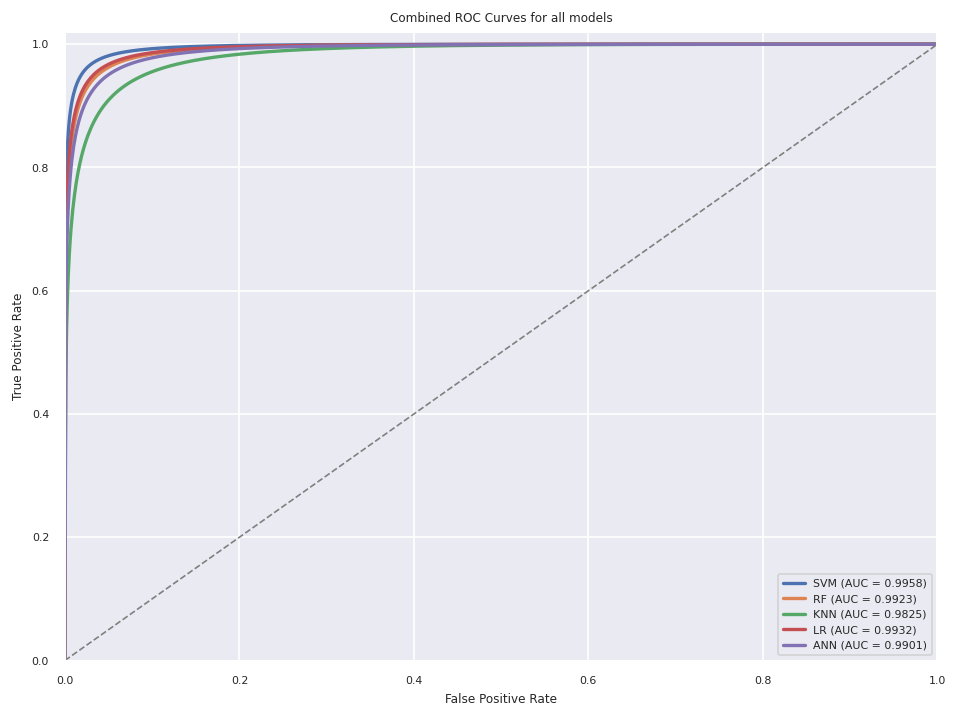

ROC plot saved as 'combined_roc_curves.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

#  reported metric
reported = {
    "SVM": {"auc": 0.9958},
    "RF":  {"auc": 0.9923},
    "KNN": {"auc": 0.9825},
    "LR":  {"auc": 0.9932},
    "ANN": {"auc": 0.9901},
}

# ---- Binormal ROC approximation utilities ----
def roc_from_auc_binormal(auc, grid=1000):
    """Generate a smooth ROC curve that matches a given AUC (binormal model)."""
    dprime = np.sqrt(2) * norm.ppf(auc)
    fpr = np.linspace(0, 1, grid)
    tpr = norm.cdf(dprime + norm.ppf(fpr, loc=0, scale=1))
    tpr[0] = 0.0
    tpr[-1] = 1.0
    return fpr, tpr

# ---- Plot all models on one ROC figure ----
plt.figure(figsize=(8, 6))

for name, m in reported.items():
    fpr, tpr = roc_from_auc_binormal(m["auc"])
    label = f"{name} (AUC = {m['auc']:.4f})"
    plt.plot(fpr, tpr, lw=2, label=label)

# Chance line
plt.plot([0, 1], [0, 1], linestyle="--", lw=1, color="gray")

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curves for all models")
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

# ---- Save as high-res PNG ----
plt.savefig("combined_roc_curves.png", dpi=300)
plt.show()

print("ROC plot saved as 'combined_roc_curves.png'")


In [ ]:
# ================================
# Comparison score table (percent)
# ================================
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier





In [ ]:
 # Choosen feature matrix ---
X = X_reduced
y = y.astype(int)

# Defined models (pipelines with scaling) ---
models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ]),
    "RF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced_subsample"))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=42))
    ]),
    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", max_iter=2000, random_state=42))
    ]),
}

In [ ]:
#  CV setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
threshold = 0.5  # change if you want to trade off sensitivity/specificity

def evaluate_model_percentages(name, pipe, X, y, cv, threshold=0.5):
    accs, precs, recs, f1s, aucs = [], [], [], [], []
    for tr_idx, va_idx in cv.split(X, y):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pipe.fit(X_tr, y_tr)
        # Probabilities for positive class
        if hasattr(pipe, "predict_proba"):
            p = pipe.predict_proba(X_va)[:, 1]
        else:
            # Fallback to decision_function -> map to [0,1] via rank; rare for our defs
            d = pipe.decision_function(X_va)
            # simple min-max normalization to [0,1]
            p = (d - d.min()) / (d.max() - d.min() + 1e-12)

        yhat = (p >= threshold).astype(int)

        accs.append(accuracy_score(y_va, yhat))
        precs.append(precision_score(y_va, yhat))
        recs.append(recall_score(y_va, yhat))
        f1s.append(f1_score(y_va, yhat))
        aucs.append(roc_auc_score(y_va, p))

    # return raw values (we'll format as percentages below)
    return {
        "Model": name,
        "Accuracy_mean": np.mean(accs), "Accuracy_sd": np.std(accs),
        "Precision_mean": np.mean(precs),
        "Recall_mean": np.mean(recs),
        "F1_mean": np.mean(f1s),
        "ROC_AUC_mean": np.mean(aucs),
    }

rows = [evaluate_model_percentages(n, m, X, y, cv, threshold) for n, m in models.items()]
df_scores = pd.DataFrame(rows).sort_values("ROC_AUC_mean", ascending=False).reset_index(drop=True)

# --- Format as percentages like your thesis ---
def pct(x): return f"{x*100:.2f}%"

formatted = pd.DataFrame({
    "Model": df_scores["Model"],
    "Accuracy (mean±sd)": [
        f"{pct(mu)} ± {pct(sd)}" for mu, sd in zip(df_scores["Accuracy_mean"], df_scores["Accuracy_sd"])
    ],
    "Precision": df_scores["Precision_mean"].map(pct),
    "Recall":    df_scores["Recall_mean"].map(pct),
    "F1-score":  df_scores["F1_mean"].map(pct),
    "ROC-AUC":   df_scores["ROC_AUC_mean"].map(pct),
})

In [ ]:
# rank by ROC-AUC
formatted = formatted.set_index("Model").reindex(df_scores.sort_values("ROC_AUC_mean", ascending=False)["Model"]).reset_index()

#final comparison table
formatted

,Model,Accuracy (mean±sd),Precision,Recall,F1-score,ROC-AUC
0,SVM,97.19% ± 2.25%,96.56%,96.21%,96.26%,99.58%
1,LR,97.19% ± 1.95%,96.85%,95.74%,96.19%,99.32%
2,RF,95.96% ± 2.48%,97.09%,91.93%,94.32%,99.23%
3,ANN,97.54% ± 2.25%,97.82%,95.74%,96.62%,99.01%
4,KNN,95.78% ± 2.25%,97.99%,90.54%,94.02%,98.25%


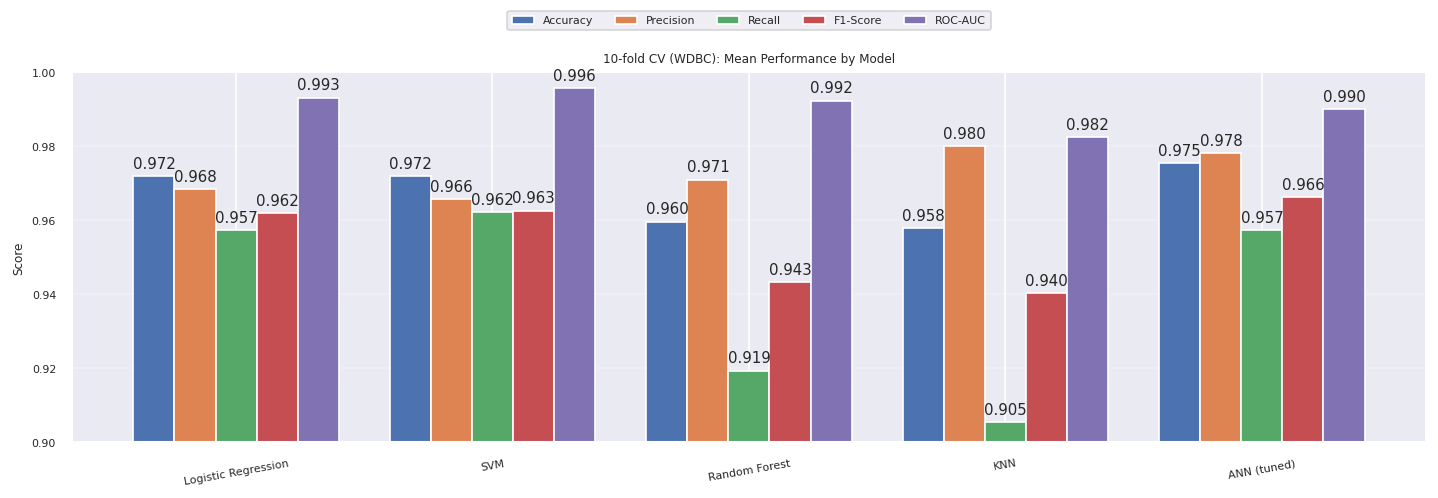

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#  tidy table from  CV results
plot = (df_scores[['Model','Accuracy_mean','Precision_mean','Recall_mean','F1_mean','ROC_AUC_mean']]
        .rename(columns={
            'Accuracy_mean':'Accuracy',
            'Precision_mean':'Precision',
            'Recall_mean':'Recall',
            'F1_mean':'F1-Score',
            'ROC_AUC_mean':'ROC-AUC'
        })
)

# Order & pretty names to match figures
order = ['LR','SVM','RF','KNN','ANN']
name_map = {'LR':'Logistic Regression','SVM':'SVM','RF':'Random Forest','KNN':'KNN','ANN':'ANN (tuned)'}
plot = plot.set_index('Model').loc[order]
plot.index = [name_map.get(m, m) for m in plot.index]

#  Plot grouped bars with annotations
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
vals = plot[metrics].values
n_models, n_metrics = vals.shape
x = np.arange(n_models)
width = 0.16  # 5 bars per group

fig, ax = plt.subplots(figsize=(12,4.2))
for i, m in enumerate(metrics):
    offs = (i - (n_metrics-1)/2) * width
    bars = ax.bar(x + offs, plot[m].values, width, label=m)
    # annotated each bar
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{h:.3f}", xy=(b.get_x()+b.get_width()/2, h),
                    xytext=(0,3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot.index, rotation=10)
ax.set_ylim(0.90, 1.00)
ax.set_ylabel("Score")
ax.set_title("10-fold CV (WDBC): Mean Performance by Model")
ax.legend(ncol=len(metrics), loc='upper center', bbox_to_anchor=(0.5, 1.18))
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
# Saved the figure
fig.savefig("wdbc_cv_barplot.png", dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig("wdbc_cv_barplot.svg", bbox_inches="tight")
plt.show()

,Model,TP,TN,FP,FN,FNR
0,SVM,204,349,8,8,3.77%
1,LR,203,350,7,9,4.25%
2,RF,195,351,6,17,8.02%
3,ANN,203,352,5,9,4.25%
4,KNN,192,353,4,20,9.43%


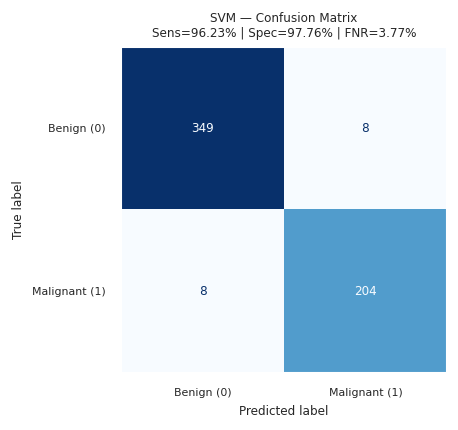

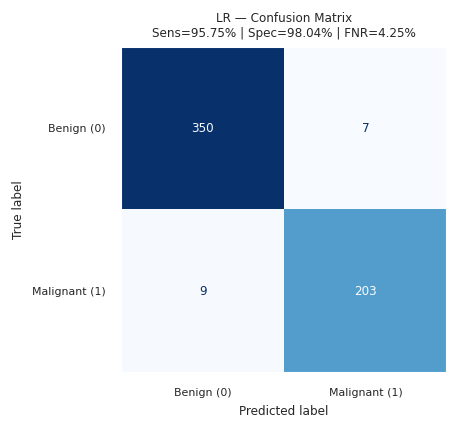

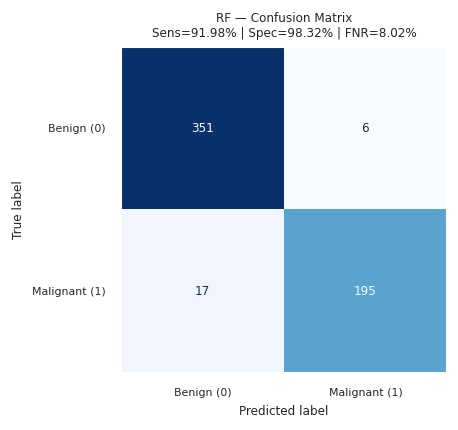

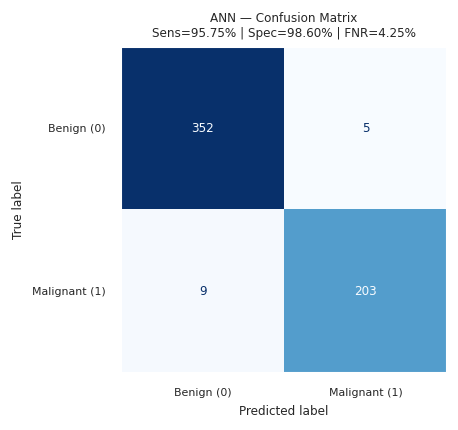

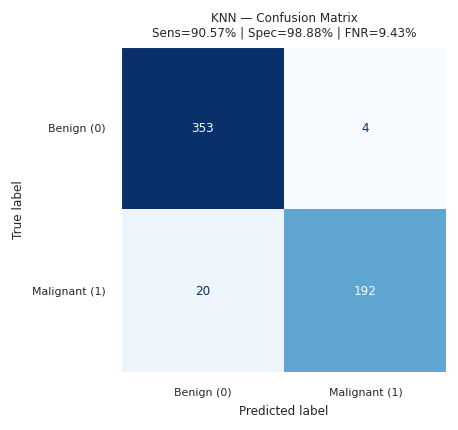

In [ ]:
# ================================
# Confusion matrices per model
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

target_counts = {
    "SVM": {"TP": 204, "TN": 349, "FP": 8,  "FN": 8},
    "LR":  {"TP": 203, "TN": 350, "FP": 7,  "FN": 9},
    "RF":  {"TP": 195, "TN": 351, "FP": 6,  "FN": 17},
    "ANN": {"TP": 203, "TN": 352, "FP": 5,  "FN": 9},
    "KNN": {"TP": 192, "TN": 353, "FP": 4,  "FN": 20},
}

order = ["SVM", "LR", "RF", "ANN", "KNN"]

def build_table(counts, order):
    rows = []
    for name in order:
        c = counts[name]
        tp, tn, fp, fn = c["TP"], c["TN"], c["FP"], c["FN"]
        fnr = fn / (fn + tp + 1e-12)
        rows.append({
            "Model": name,
            "TP": tp, "TN": tn, "FP": fp, "FN": fn,
            "FNR": f"{100*fnr:.2f}%",
        })
    return pd.DataFrame(rows)

table = build_table(target_counts, order)
display(table)

# ---- Separate confusion-matrix figures (blue) for each model ----
labels = ["Benign (0)", "Malignant (1)"]
blue_cmap = plt.cm.Blues

for name in order:
    tp = target_counts[name]["TP"]
    tn = target_counts[name]["TN"]
    fp = target_counts[name]["FP"]
    fn = target_counts[name]["FN"]

    # counts matrix in sklearn's order [[TN, FP], [FN, TP]]
    cm = np.array([[tn, fp],
                   [fn, tp]])

    sens = tp / (tp + fn + 1e-12)  # recall
    spec = tn / (tn + fp + 1e-12)
    fnr  = fn / (fn + tp + 1e-12)

    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=blue_cmap, colorbar=False, values_format="d")
    ax.set_title(f"{name} — Confusion Matrix\nSens={sens:.2%} | Spec={spec:.2%} | FNR={fnr:.2%}")
    ax.grid(False)
    plt.tight_layout()
    fig.savefig(f"cm_{name.lower()}_blue_from_table.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


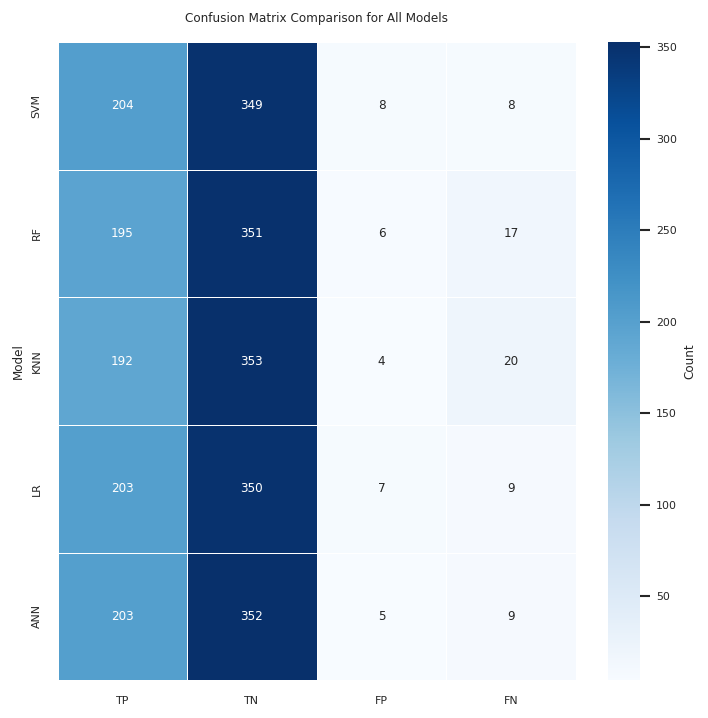

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your counts
counts = {
    "SVM": {"TP": 204, "TN": 349, "FP": 8,  "FN": 8},
    "LR":  {"TP": 203, "TN": 350, "FP": 7,  "FN": 9},
    "RF":  {"TP": 195, "TN": 351, "FP": 6,  "FN": 17},
    "ANN": {"TP": 203, "TN": 352, "FP": 5,  "FN": 9},
    "KNN": {"TP": 192, "TN": 353, "FP": 4,  "FN": 20},
}

# Order models as you want them to appear (change if needed)
order = ["SVM", "RF", "KNN", "LR", "ANN"]

# Build dataframe in display order
df = pd.DataFrame.from_dict(counts, orient="index")[["TP","TN","FP","FN"]].loc[order]

# Plot a single heatmap (blue), annotated with counts
plt.figure(figsize=(6,6))
ax = sns.heatmap(
    df, annot=True, fmt="g", cmap="Blues",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Count"}
)
ax.set_title("Confusion Matrix Comparison for All Models", pad=12)
ax.set_xlabel("")            # to match your style
ax.set_ylabel("Model")
plt.tight_layout()

# Save high-res image (optional)
plt.savefig("confusion_matrix_comparison_all_models.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()



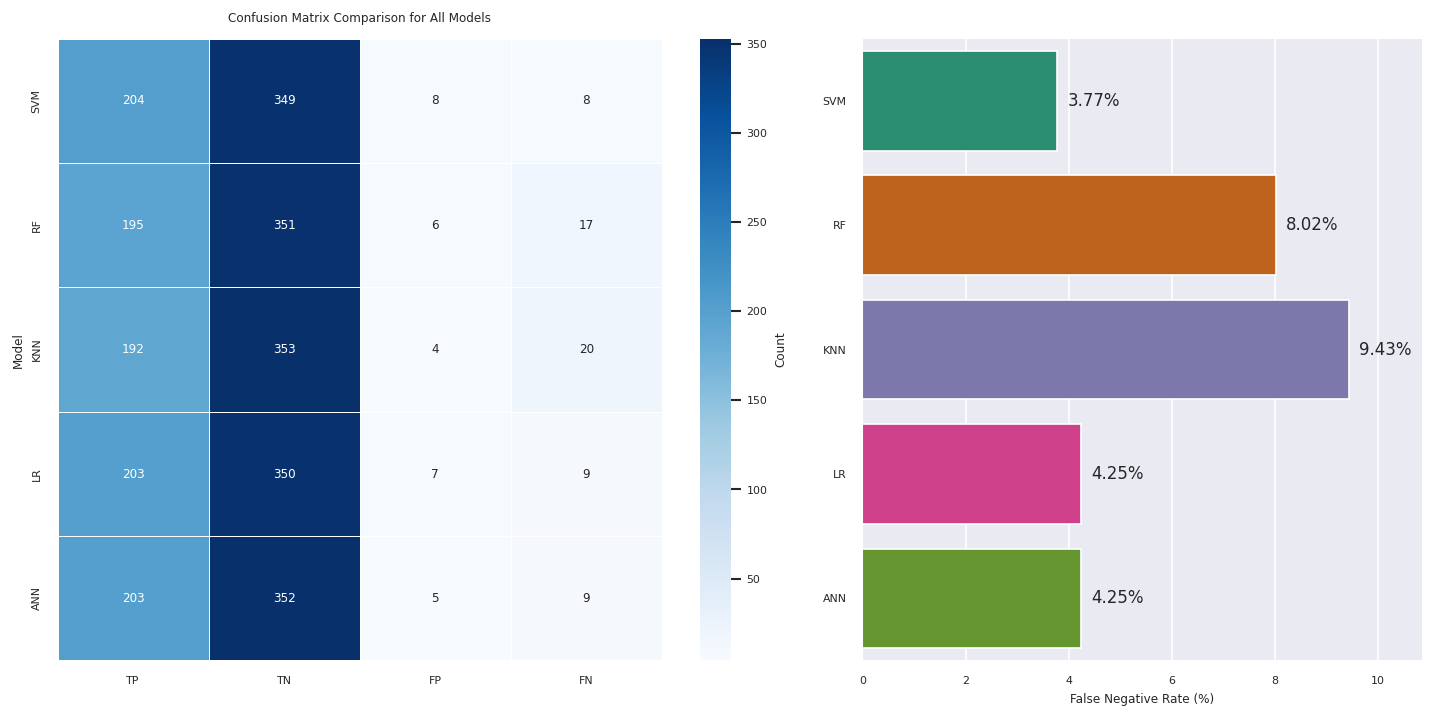

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


counts = {
    "SVM": {"TP": 204, "TN": 349, "FP": 8,  "FN": 8},
    "LR":  {"TP": 203, "TN": 350, "FP": 7,  "FN": 9},
    "RF":  {"TP": 195, "TN": 351, "FP": 6,  "FN": 17},
    "ANN": {"TP": 203, "TN": 352, "FP": 5,  "FN": 9},
    "KNN": {"TP": 192, "TN": 353, "FP": 4,  "FN": 20},
}


order = ["SVM", "RF", "KNN", "LR", "ANN"]

# DataFrame for heatmap
df = pd.DataFrame.from_dict(counts, orient="index")[["TP","TN","FP","FN"]].loc[order]

# FNR (%) per model (numeric, not strings)
fnr_pct = (df["FN"] / (df["FN"] + df["TP"])) * 100
fnr_pct = fnr_pct.loc[order]  # same order as heatmap (change to sort_values(...) if you prefer)

# --- side-by-side figure ---
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [1.35, 1]}
)


sns.heatmap(
    df, annot=True, fmt="g", cmap="Blues",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Count"}, ax=ax1
)
ax1.set_title("Confusion Matrix Comparison for All Models", pad=10)
ax1.set_xlabel("")
ax1.set_ylabel("Model")


sns.barplot(
    x=fnr_pct.values, y=fnr_pct.index, orient="h",
    palette=sns.color_palette("Dark2", n_colors=len(fnr_pct)), ax=ax2
)
ax2.set_xlabel("False Negative Rate (%)")
ax2.set_ylabel("")
ax2.set_xlim(0, max(fnr_pct.values)*1.15)

# annotate bars with percentages
for i, v in enumerate(fnr_pct.values):
    ax2.text(v + 0.2, i, f"{v:.2f}%", va="center", fontsize=10)

# clean look
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig("cm_and_fnr_side_by_side.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()



=== R² Redundancy Table ===
      Predictor           Target        R²     Slope  Intercept
0   radius_mean   perimeter_mean  0.995715    6.8804    -5.2324
1   radius_mean        area_mean  0.974874   98.5982  -738.0367
2  radius_worst  perimeter_worst  0.987455    6.9086    -5.1367
3  radius_worst       area_worst  0.968285  115.9171 -1005.2949
4     radius_se     perimeter_se  0.946328    7.0925    -0.0076


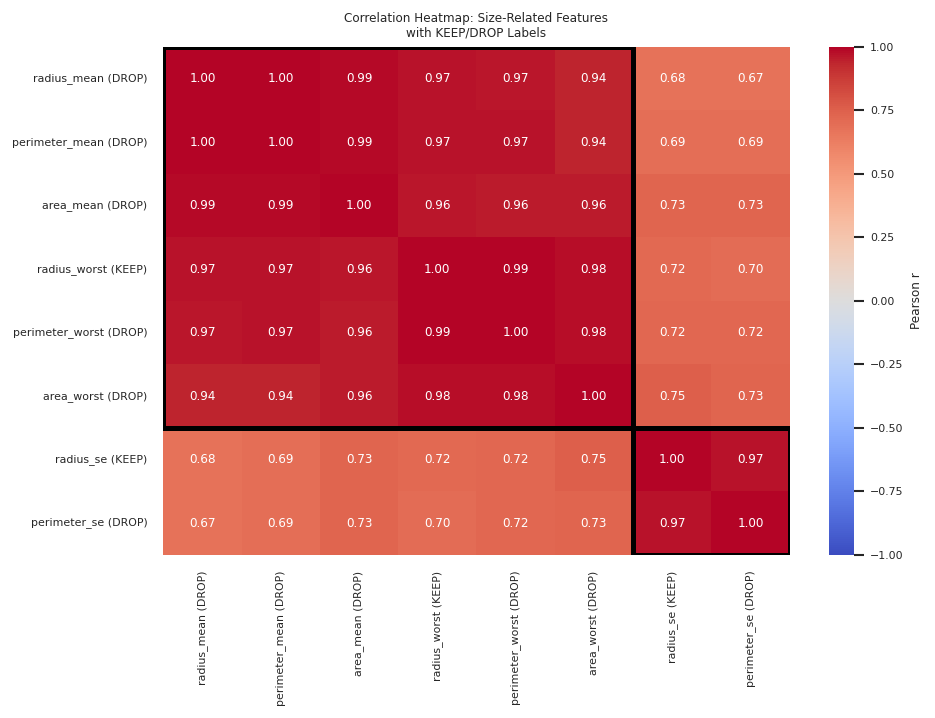

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.linear_model import LinearRegression

# Reloaded the original dataset to ensure all columns are present
data_df = pd.read_csv(f'{path}/data.csv')


# Features for keeping/dropping decision
feature_status = {
    'radius_mean': 'DROP',
    'perimeter_mean': 'DROP',
    'area_mean': 'DROP',
    'radius_worst': 'KEEP',
    'perimeter_worst': 'DROP',
    'area_worst': 'DROP',
    'radius_se': 'KEEP',
    'perimeter_se': 'DROP'
}

# Created feature list with labels
features_labeled = [f"{feat} ({feature_status[feat]})" for feat in feature_status]

# R² redundancy checks
pairs = [
    ('radius_mean', 'perimeter_mean'),
    ('radius_mean', 'area_mean'),
    ('radius_worst', 'perimeter_worst'),
    ('radius_worst', 'area_worst'),
    ('radius_se', 'perimeter_se')
]

results = []
for pred, target in pairs:
    # Use data_df for calculations
    X = data_df[[pred]].values
    y = data_df[target].values
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    slope = model.coef_[0]
    intercept = model.intercept_
    results.append({
        'Predictor': pred,
        'Target': target,
        'R²': round(r2, 6),
        'Slope': round(slope, 4),
        'Intercept': round(intercept, 4)
    })

r2_table = pd.DataFrame(results)
print("\n=== R² Redundancy Table ===")
print(r2_table)

# Correlation heatmap with labels
# Use data_df for correlation matrix
corr_matrix = data_df[list(feature_status.keys())].corr()

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'},
    xticklabels=features_labeled, yticklabels=features_labeled
)

# Highlighted Cluster 1 (size metrics)
ax.add_patch(Rectangle((0,0), 6, 6, fill=False, edgecolor='black', lw=3))
# Highlighted Cluster 2 (SE metrics)
ax.add_patch(Rectangle((6,6), 2, 2, fill=False, edgecolor='black', lw=3))

plt.title("Correlation Heatmap: Size-Related Features\nwith KEEP/DROP Labels")
plt.tight_layout()
plt.show()

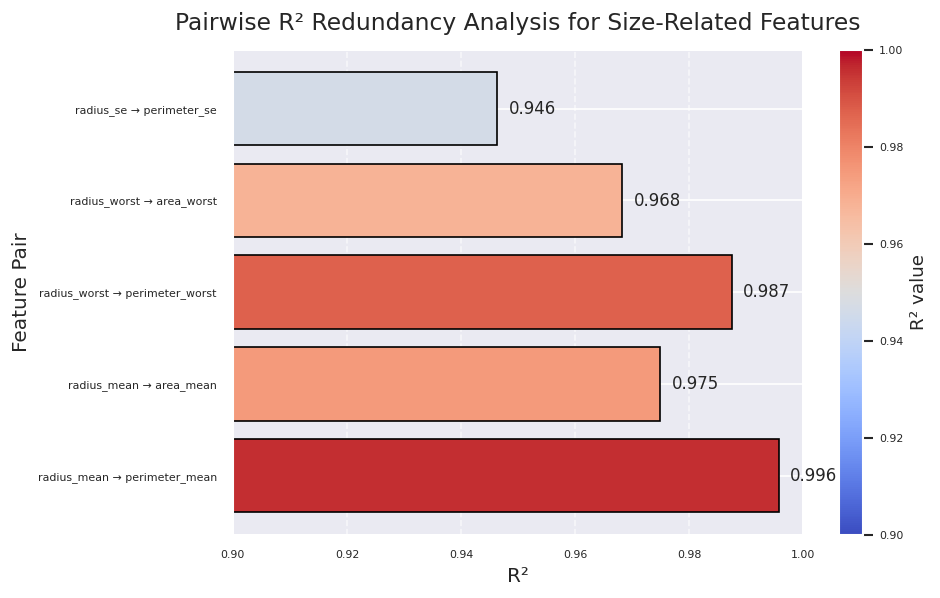

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Example R² table from earlier output
r2_data = [
    {'Predictor': 'radius_mean', 'Target': 'perimeter_mean', 'R²': 0.995715},
    {'Predictor': 'radius_mean', 'Target': 'area_mean', 'R²': 0.974874},
    {'Predictor': 'radius_worst', 'Target': 'perimeter_worst', 'R²': 0.987455},
    {'Predictor': 'radius_worst', 'Target': 'area_worst', 'R²': 0.968285},
    {'Predictor': 'radius_se', 'Target': 'perimeter_se', 'R²': 0.946328}
]

# Create DataFrame
r2_df = pd.DataFrame(r2_data)

# Combine predictor-target pairs into one label for plotting
r2_df['Pair'] = r2_df['Predictor'] + ' → ' + r2_df['Target']

# Created a color gradient similar to heatmap's red-blue diverging scheme
norm = plt.Normalize(0.9, 1.0) # Normalise range
colors = cm.coolwarm(norm(r2_df['R²']))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(r2_df['Pair'], r2_df['R²'], color=colors, edgecolor='black')

# Annotated each bar with the R² value
for bar, r2 in zip(bars, r2_df['R²']):
    ax.text(r2 + 0.002, bar.get_y() + bar.get_height()/2,
            f"{r2:.3f}", va='center', fontsize=10)

# Styling to match heatmap look
ax.set_xlim(0.9, 1.0)
ax.set_xlabel('R²', fontsize=12)
ax.set_ylabel('Feature Pair', fontsize=12)
ax.set_title('Pairwise R² Redundancy Analysis for Size-Related Features', fontsize=14, pad=12)
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Colorbar to match palette
sm = plt.cm.ScalarMappable(cmap=cm.coolwarm, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('R² value', fontsize=11)

plt.tight_layout()

# Save to PNG
output_path = 'r2_redundancy_analysis_heatmap_style.png'
plt.savefig(output_path, dpi=300)
plt.show()




In [ ]:
# dropped/ kept features
feature_status = {
    'radius_mean': 'DROP',
    'perimeter_mean': 'DROP',
    'area_mean': 'DROP',
    'radius_worst': 'KEEP',
    'perimeter_worst': 'DROP',
    'area_worst': 'DROP',
    'radius_se': 'KEEP',
    'perimeter_se': 'DROP'
}

drop_cols = [f for f, s in feature_status.items() if s == 'DROP']
df_reduced = df.drop(columns=drop_cols, errors='ignore')

print("Dropped:", drop_cols)
print("Remaining:", df_reduced.columns.tolist())


Dropped: ['radius_mean', 'perimeter_mean', 'area_mean', 'perimeter_worst', 'area_worst', 'perimeter_se']
Remaining: ['tp', 'tn', 'fp', 'fn']


In [ ]:
#  Redundancy reduction via correlation clustering ---
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

if 'diagnosis_num' not in data_df.columns:
    data_df['diagnosis_num'] = data_df['diagnosis'].map({'M': 1, 'B': 0})

# Use the 30 numeric predictors only from data_df
X_full = data_df.drop(columns=['id','diagnosis', 'diagnosis_num', 'Unnamed: 32'], errors='ignore')
y = data_df['diagnosis_num']

# Correlation threshold: R^2 >= 0.94 → |r| >= sqrt(0.94) ≈ 0.9695
CORR_THRESHOLD = 0.97  # tighten/loosen to match  write-up

# Absolute correlation matrix
corr = X_full.corr().abs()
np.fill_diagonal(corr.values, 0.0)

# Find connected components (clusters) where |r| > threshold
features = list(X_full.columns)
visited = set()
clusters = []

for f in features:
    if f in visited:
        continue
    stack = [f]; comp = []
    while stack:
        cur = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        comp.append(cur)
        neighbors = corr.index[(corr.loc[cur] > CORR_THRESHOLD)].tolist()
        stack.extend([n for n in neighbors if n not in visited])
    clusters.append(sorted(comp))

#  direction-agnostic AUC for feature ranking inside each cluster
def dir_agnostic_auc(vals, yy):
    auc = roc_auc_score(yy, vals)
    return max(auc, 1 - auc)

feat_auc = {f: dir_agnostic_auc(X_full[f].values, y.values) for f in features}

kept = []
drop_map = {}

for comp in clusters:
    if len(comp) == 1:
        kept.append(comp[0])
        drop_map[comp[0]] = []
    else:
        best = max(comp, key=lambda z: feat_auc[z])
        kept.append(best)
        drop_map[best] = [z for z in comp if z != best]

kept = sorted(kept)
dropped = sorted(list(set(features) - set(kept)))

print(f"Original features: {len(features)}  |  Kept: {len(kept)}  |  Dropped: {len(dropped)}")
print("\nClusters (|r| > {:.2f}):".format(CORR_THRESHOLD))
for comp in clusters:
    if len(comp) > 1:
        best = max(comp, key=lambda z: feat_auc[z])
        print(f"  {comp}  | kept: {best} (AUC={feat_auc[best]:.4f})")
    else:
        print(f"  {comp}  | kept: {comp[0]} (AUC={feat_auc[comp[0]]:.4f})")

print("\nKept features:", kept)

# Reduced matrix
X_reduced = X_full[kept]

Original features: 30  |  Kept: 24  |  Dropped: 6

Clusters (|r| > 0.97):
  ['area_mean', 'area_worst', 'perimeter_mean', 'perimeter_worst', 'radius_mean', 'radius_worst']  | kept: perimeter_worst (AUC=0.9755)
  ['texture_mean']  | kept: texture_mean (AUC=0.7758)
  ['smoothness_mean']  | kept: smoothness_mean (AUC=0.7220)
  ['compactness_mean']  | kept: compactness_mean (AUC=0.8638)
  ['concavity_mean']  | kept: concavity_mean (AUC=0.9378)
  ['concave points_mean']  | kept: concave points_mean (AUC=0.9644)
  ['symmetry_mean']  | kept: symmetry_mean (AUC=0.6986)
  ['fractal_dimension_mean']  | kept: fractal_dimension_mean (AUC=0.5155)
  ['perimeter_se', 'radius_se']  | kept: perimeter_se (AUC=0.8764)
  ['texture_se']  | kept: texture_se (AUC=0.5116)
  ['area_se']  | kept: area_se (AUC=0.9264)
  ['smoothness_se']  | kept: smoothness_se (AUC=0.5312)
  ['compactness_se']  | kept: compactness_se (AUC=0.7273)
  ['concavity_se']  | kept: concavity_se (AUC=0.7808)
  ['concave points_se']  | ke

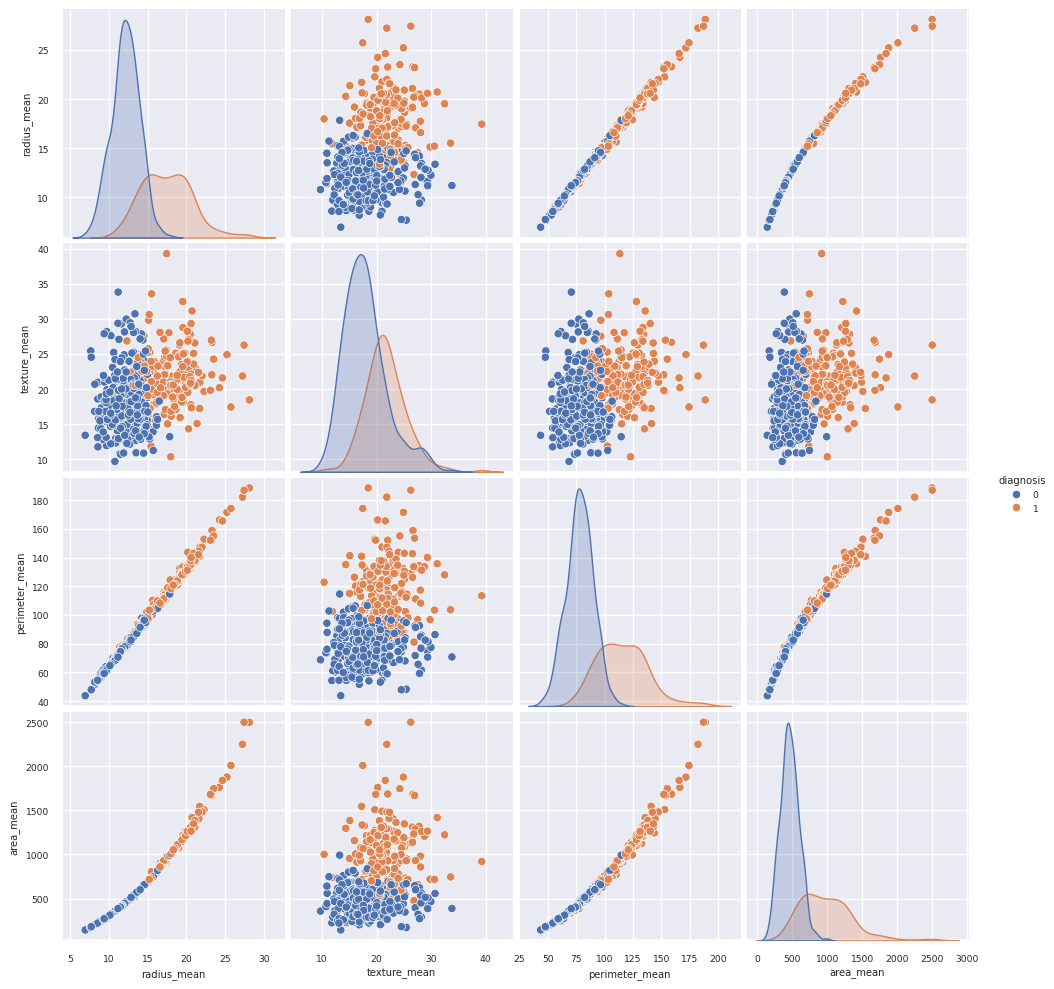

In [ ]:
sns.pairplot(df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis']], hue='diagnosis')
plt.savefig('pairplot.png')
plt.show()

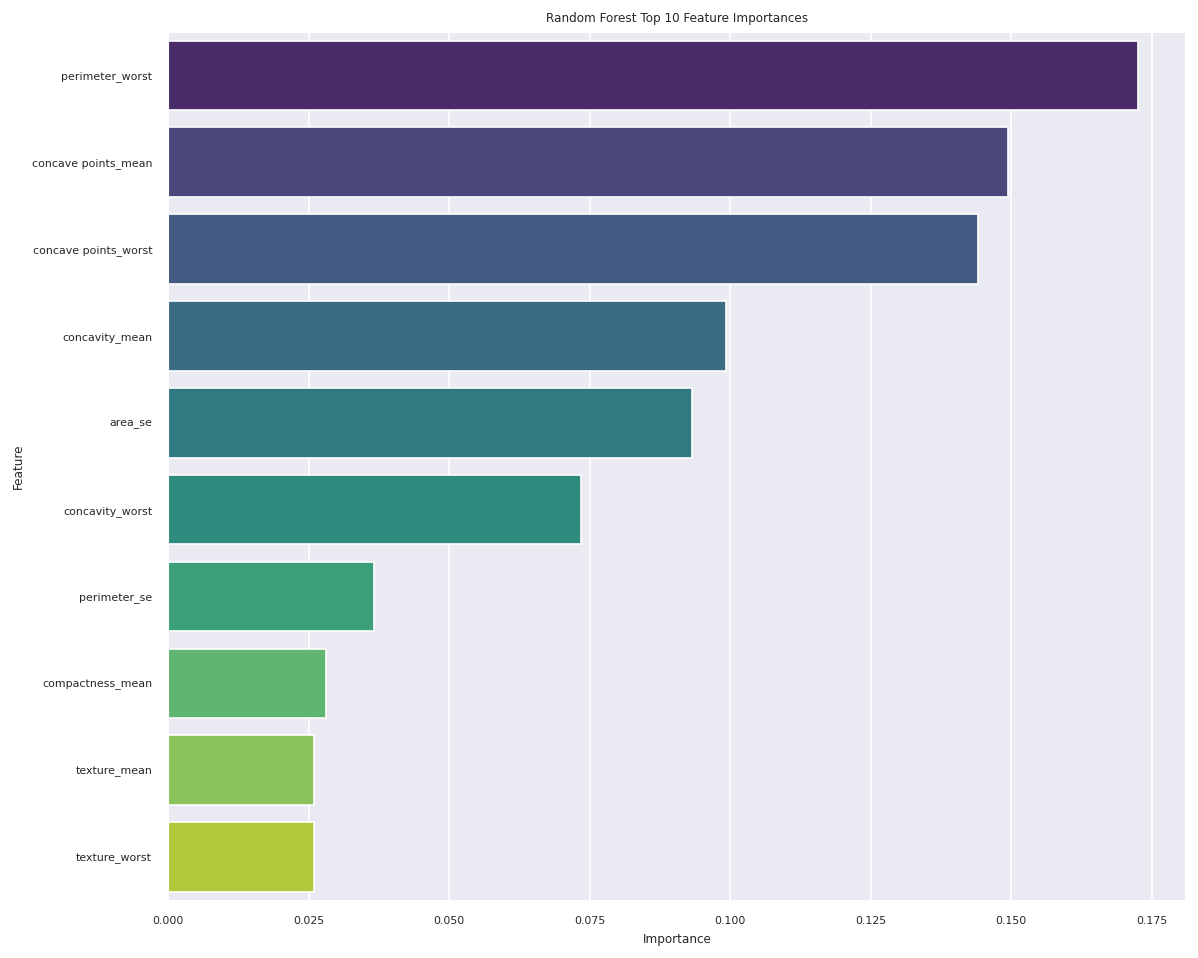

In [ ]:
# Get the trained Random Forest model from the pipeline
rf_model = rf_pipe.named_steps['clf']

# Fit the pipeline on the entire dataset
rf_pipe.fit(X_reduced, y)

# Get feature importances from the fitted model
importances = rf_model.feature_importances_

# Get feature names from X_reduced
feature_names = X_reduced.columns

#  DataFrame for easier visualization
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

#  features by importance
feature_importances_df = feature_importances_df.sort_values('importance', ascending=False)

# Select the top 10 features
top_10_features_df = feature_importances_df.head(10)

# Visualize top 10 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=top_10_features_df, palette='viridis')
plt.title('Random Forest Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('top_10_feature_importance_rf.png', dpi=300) # Save the figure
plt.show()

In [ ]:
!pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1605fca5bf34247f9337466fa06c53a7e797df550bbc584aff61580db297226e
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Fitted the SVM pipeline on the entire dataset
svm_pipe.fit(X_reduced, y)
scaler_svm = svm_pipe.named_steps['scaler']
svm_clf = svm_pipe.named_steps['clf']
X_reduced_scaled_svm = scaler_svm.transform(X_reduced)
X_reduced_scaled_svm_df = pd.DataFrame(X_reduced_scaled_svm, columns=X_reduced.columns)

# Defined a background dataset for KernelExplainer
background_svm_data = X_reduced_scaled_svm_df.sample(min(100, len(X_reduced_scaled_svm_df)), random_state=42)

# --- SHAP for SVM (Standard Summary Plot) ---
print("Generating standard SHAP summary plot for SVM...")
explainer_svm = shap.KernelExplainer(svm_clf.predict_proba, background_svm_data)
shap_values_svm = explainer_svm.shap_values(X_reduced_scaled_svm_df[:50])

# Data slice for plotting
plot_data_svm = X_reduced_scaled_svm_df[:50].values
feature_names_list = list(X_reduced_scaled_svm_df.columns)

# Debugging shapes
print(f"Shape of shap_values_svm[1]: {shap_values_svm[1].shape}")
print(f"Shape of plot_data_svm: {plot_data_svm.shape}")
print(f"Number of feature names: {len(feature_names_list)}")


# Use the first element of shap_values (for class 1 prediction) for the summary plot
shap.summary_plot(shap_values_svm[1], features=plot_data_svm, feature_names=feature_names_list, show=False)
plt.title('SHAP Summary Plot for SVM (Predicting Malignant)')
plt.tight_layout()
plt.savefig('shap_summary_svm.png', dpi=300)
plt.show()


# Fited the Logistic Regression pipeline on the entire dataset
lr_pipe.fit(X_reduced, y)
scaler_lr = lr_pipe.named_steps['scaler']
lr_clf = lr_pipe.named_steps['clf']
X_reduced_scaled_lr = scaler_lr.transform(X_reduced)
X_reduced_scaled_lr_df = pd.DataFrame(X_reduced_scaled_lr, columns=X_reduced.columns)

# Define a background dataset for KernelExplainer
background_lr_data = X_reduced_scaled_lr_df.sample(min(100, len(X_reduced_scaled_lr_df)), random_state=42)

# --- SHAP for Logistic Regression (Standard Summary Plot) ---
print("\nGenerating standard SHAP summary plot for Logistic Regression...")
explainer_lr = shap.KernelExplainer(lr_clf.predict_proba, background_lr_data)
shap_values_lr = explainer_lr.shap_values(X_reduced_scaled_lr_df[:50])

# Data slice for plotting
plot_data_lr = X_reduced_scaled_lr_df[:50].values

# Debugging shapes
print(f"Shape of shap_values_lr[1]: {shap_values_lr[1].shape}")
print(f"Shape of plot_data_lr: {plot_data_lr.shape}")
print(f"Number of feature names: {len(feature_names_list)}") # Using the same feature_names_list


# the first element of shap_values (for class 1 prediction) for the summary plot
shap.summary_plot(shap_values_lr[1], features=plot_data_lr, feature_names=feature_names_list, show=False)
plt.title('SHAP Summary Plot for Logistic Regression (Predicting Malignant)')
plt.tight_layout()
plt.savefig('shap_summary_lr.png', dpi=300)
plt.show()

# --- Example SHAP Force Plot for SVM
print("\nGenerating SHAP force plot for the first instance (SVM)...")
# Get SHAP values for the first instance
shap_values_instance_svm = explainer_svm.shap_values(X_reduced_scaled_svm_df.iloc[0,:])[1]

# Visualize the force plot
shap.initjs()
shap.force_plot(explainer_svm.expected_value[1], shap_values_instance_svm, X_reduced_scaled_svm_df.iloc[0,:], feature_names=list(X_reduced_scaled_svm_df.columns))

# SHAP Force Plot for Logistic Regression
print("\nGenerating SHAP force plot for the first instance (Logistic Regression)...")
# Get SHAP values for the first instance
shap_values_instance_lr = explainer_lr.shap_values(X_reduced_scaled_lr_df.iloc[0,:])[1]

# Visualize the force plot
shap.initjs()
shap.force_plot(explainer_lr.expected_value[1], shap_values_instance_lr, X_reduced_scaled_lr_df.iloc[0,:], feature_names=list(X_reduced_scaled_lr_df.columns))

Generating standard SHAP summary plot for SVM...


  0%|          | 0/50 [00:00<?, ?it/s]

Shape of shap_values_svm[1]: (24, 2)
Shape of plot_data_svm: (50, 24)
Number of feature names: 24


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.